# k-NN - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

The math behind "you are like your neighbors" - distances, voting, and the
geometry that makes scaling non-negotiable. All demos on REAL penguin data.

### What you'll learn
- Euclidean vs Manhattan distance, computed by hand on real rows
- The vote: majority vs distance-weighted
- Why feature ranges distort neighborhoods (the scaling proof)
- Bias-variance reading of k

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins").dropna()
except Exception as e:
    print("offline?", e); raise

two = pen[["bill_length_mm", "flipper_length_mm"]].values
species = pen["species"].values

### 1. Distances by hand - two real penguins


In [2]:
a, b = two[0], two[1]
euclid = np.sqrt(((a - b) ** 2).sum())
manhattan = np.abs(a - b).sum()

print(f"penguin A: bill {a[0]:.1f}mm | flipper {a[1]:.1f}mm ({species[0]})")
print(f"penguin B: bill {b[0]:.1f}mm | flipper {b[1]:.1f}mm ({species[1]})")
print(f"\nEuclidean  d = sqrt({((a-b)**2).sum():.2f}) = {euclid:.3f}")
print(f"Manhattan  d = {' + '.join(f'{v:.1f}' for v in np.abs(a-b))} = {manhattan:.3f}")
print("→ Euclidean is the default (metric='minkowski', p=2)")

penguin A: bill 39.1mm | flipper 181.0mm (Adelie)
penguin B: bill 39.5mm | flipper 186.0mm (Adelie)

Euclidean  d = sqrt(25.16) = 5.016
Manhattan  d = 0.4 + 5.0 = 5.400
→ Euclidean is the default (metric='minkowski', p=2)


### 2. The scaling trap - one big-range feature hijacks the ruler


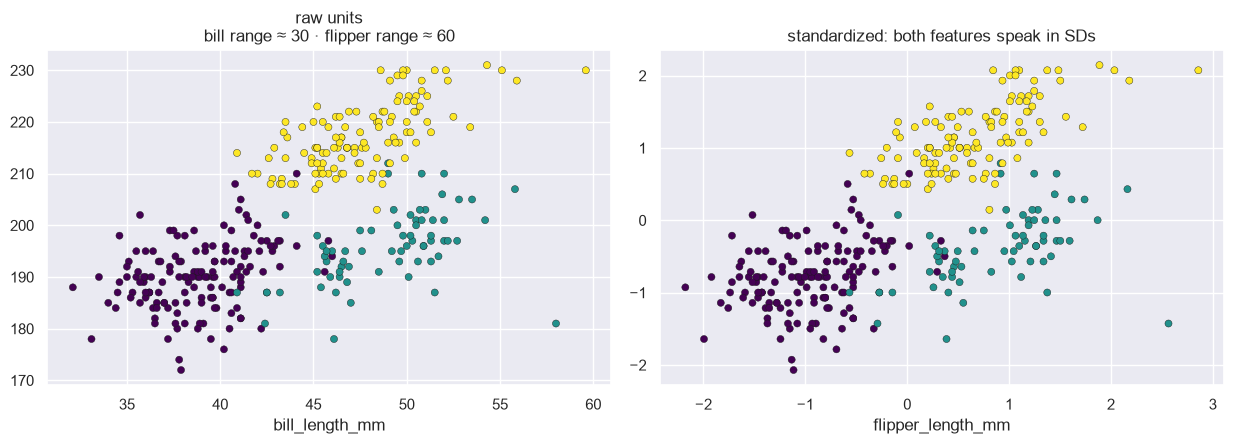

nearest neighbor of A (raw):      #0 → Adelie
nearest neighbor of A (scaled):   #5 → Adelie


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].scatter(pen.bill_length_mm, pen.flipper_length_mm,
                c=pd.factorize(species)[0], cmap="viridis", s=26,
                edgecolor="k", lw=.3)
axes[0].set_title(f"raw units\nbill range ≈ 30 · flipper range ≈ 60")

sc = StandardScaler().fit(two)
scaled = sc.transform(two)
axes[1].scatter(scaled[:, 0], scaled[:, 1],
                c=pd.factorize(species)[0], cmap="viridis", s=26,
                edgecolor="k", lw=.3)
axes[1].set_title("standardized: both features speak in SDs")
for ax, lab in zip(axes, ["bill_length_mm", "flipper_length_mm"]):
    ax.set_xlabel(lab)
plt.tight_layout(); plt.show()

# Numeric proof: nearest neighbor of penguin A before/after scaling
d_raw = np.sqrt(((two - a) ** 2).sum(axis=1)); d_raw[a is two[0]] = np.inf
nn_raw = int(np.argsort(d_raw)[0])
d_sc = np.sqrt(((scaled - scaled[0]) ** 2).sum(axis=1)); d_sc[0] = np.inf
nn_scaled = int(np.argsort(d_sc)[0])
print(f"nearest neighbor of A (raw):      #{nn_raw} → {species[nn_raw]}")
print(f"nearest neighbor of A (scaled):   #{nn_scaled} → {species[nn_scaled]}")

### 3. The vote & the k dial

For a query point q:
1. compute $d(q, x_i)$ to every labeled row
2. take the k smallest
3. predict $\text{argmax}_c \sum_{i \in \text{kNN}, y_i=c} w_i$ where
   $w_i = 1$ (`uniform`) or $w_i = 1/d_i$ (`distance`)

In [4]:
def knn_vote(q, X, ys, k, weighted=False):
    d = np.sqrt(((X - q) ** 2).sum(axis=1))
    idx = np.argsort(d)[:k]
    votes = {}
    for i in idx:
        w = (1 / max(d[i], 1e-9)) if weighted else 1
        votes[ys[i]] = votes.get(ys[i], 0) + w
    return max(votes, key=votes.get), votes

q = two[np.random.RandomState(7).choice(len(two))]
for k in [1, 5, 21]:
    pred, votes = knn_vote(q, two, species, k)
    print(f"k={k:>2}: {pred:<10} votes={votes}")

k= 1: Chinstrap  votes={'Chinstrap': 1}
k= 5: Chinstrap  votes={'Chinstrap': 5}
k=21: Chinstrap  votes={'Chinstrap': 18, 'Gentoo': 3}


### k = bias/variance knob

- **k=1**: decision follows every single dot → jagged, low bias / high variance
- **large k**: whole-region smoothing → high bias / low variance
- CV picks the sweet spot (done in `03_sklearn_implementation.ipynb`)

### Summary & key takeaways

- Prediction = local vote; training = storing data (lazy learning).
- Euclidean distance assumes comparable units - ALWAYS scale.
- `weights="distance"` lets close voters dominate open debates.
- k trades wiggliness against smoothness; choose it with cross-validation.